# Student Performance Analysis

## 1. Problem Statement

Mục tiêu của dự án là phân tích dữ liệu kết quả học tập của học sinh và 
xây dựng mô hình dự đoán khả năng đậu hoặc rớt môn học.

Bài toán được xây dựng dựa trên các yếu tố như:
- Thời gian học
- Số buổi nghỉ học
- Số lần trượt môn
- Các đặc điểm cá nhân của học sinh

Target Variable:

pass = 1 nếu học sinh đạt điểm cuối kỳ (G3) >= 10  
pass = 0 nếu học sinh có điểm cuối kỳ (G3) < 10

Dữ liệu sẽ được phân tích bằng phương pháp Exploratory Data Analysis (EDA)
để hiểu cấu trúc dữ liệu và tìm ra các yếu tố ảnh hưởng đến kết quả học tập.

## 2. Dataset Source

Dataset được sử dụng trong dự án là **Student Performance Dataset**.

Nguồn dữ liệu:
UCI Machine Learning Repository

Dataset này chứa thông tin về:
- nhân khẩu học của học sinh
- điều kiện gia đình
- thói quen học tập
- kết quả học tập

Dataset bao gồm nhiều thuộc tính có thể ảnh hưởng đến điểm số cuối kỳ.

## 3. Data Dictionary

Dưới đây là mô tả một số cột quan trọng trong dataset:

| Column | Description |
|------|-------------|
| school | Trường học của học sinh |
| sex | Giới tính của học sinh |
| age | Tuổi của học sinh |
| address | Nơi ở (urban/rural) |
| studytime | Thời gian học mỗi tuần |
| failures | Số lần trượt môn trước đó |
| absences | Số buổi nghỉ học |
| G1 | Điểm kỳ 1 |
| G2 | Điểm kỳ 2 |
| G3 | Điểm cuối kỳ |
| pass | Biến mục tiêu (1 = đậu, 0 = rớt) |


Note: Dataset gồm 30+ thuộc tính, chi tiết đầy đủ xem tại tài liệu UCI.
Trong phạm vi bài toán, nhóm tập trung vào các biến chính ảnh hưởng đến kết quả học tập.

## 4. Potential Data Issues

Một số vấn đề dữ liệu có thể ảnh hưởng đến kết quả phân tích:

### 1. Missing Values
Dataset có thể chứa dữ liệu thiếu ở một số cột.

### 2. Duplicate Records
Một số dòng dữ liệu có thể bị trùng lặp.

### 3. Class Imbalance
Số lượng học sinh đậu và rớt có thể không cân bằng.

### 4. Data Leakage
Các biến như G1 và G2 có thể có tương quan cao với G3.
Nếu sử dụng trực tiếp trong mô hình dự đoán G3, có thể gây hiện tượng data leakage.

Import Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

print("Libraries loaded successfully")

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Libraries loaded successfully


Load Dataset

In [2]:
df = pd.read_csv("../data/raw/student-mat.csv", sep=";")

df.head()

print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

Dataset shape: (395, 33)

Column names:
Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='str')

Data types:
school          str
sex             str
age           int64
address         str
famsize         str
Pstatus         str
Medu          int64
Fedu          int64
Mjob            str
Fjob            str
reason          str
guardian        str
traveltime    int64
studytime     int64
failures      int64
schoolsup       str
famsup          str
paid            str
activities      str
nursery         str
higher          str
internet        str
romantic        str
famrel        int64
freetime      int64
goout         int64
Dalc          int64
Walc          int64
healt

Dataset Shape

In [3]:
print("Dataset shape:", df.shape)

Dataset shape: (395, 33)


Column Names

In [4]:
df.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='str')

Dataset Information

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 non-null    str  
 21  inte

Statistical Summary

In [6]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


### Check Missing Values

Kiểm tra xem dataset có giá trị thiếu hay không.

In [7]:
df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

### Check Duplicate Rows

Kiểm tra xem có dòng dữ liệu nào bị trùng lặp hay không.

In [8]:
df.duplicated().sum()

np.int64(0)

### Remove Duplicate Records

In [9]:
print("Before removing duplicates:", df.shape)

df = df.drop_duplicates()

print("After removing duplicates:", df.shape)

Before removing duplicates: (395, 33)
After removing duplicates: (395, 33)


Distribution of Final Grade

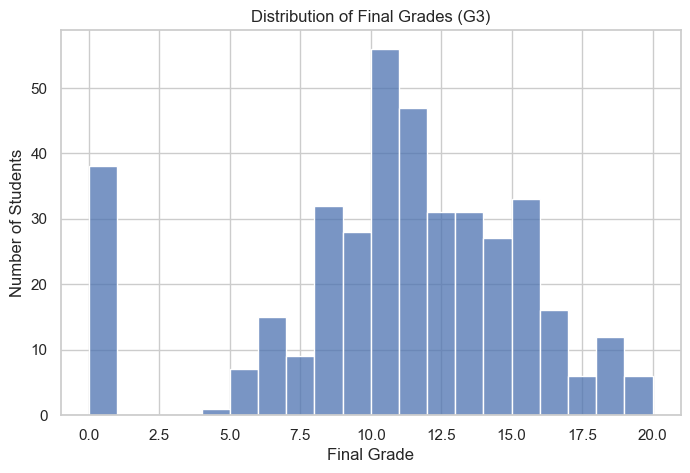

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(df["G3"], bins=20)

plt.title("Distribution of Final Grades (G3)")
plt.xlabel("Final Grade")
plt.ylabel("Number of Students")

plt.show()

 Nhận xét:
- Điểm G3 tập trung chủ yếu trong khoảng 8–14.
- Có một số học sinh có điểm rất thấp (<5), thuộc nhóm có nguy cơ rớt.

Study Time Distribution

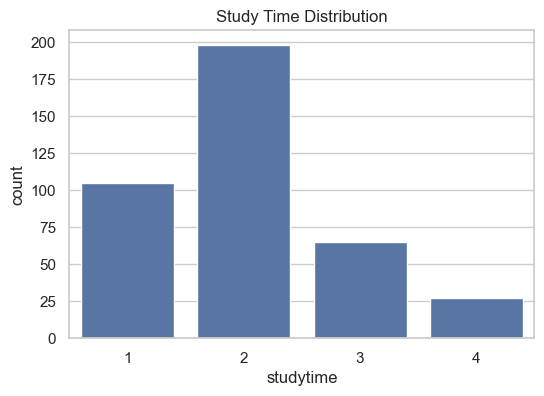

In [11]:
plt.figure(figsize=(6,4))

sns.countplot(x="studytime", data=df)

plt.title("Study Time Distribution")

plt.show()

Nhận xét:
- Phần lớn học sinh có studytime ở mức trung bình.
- Ít học sinh học ở mức cao nhất.

Study Time vs Final Grade

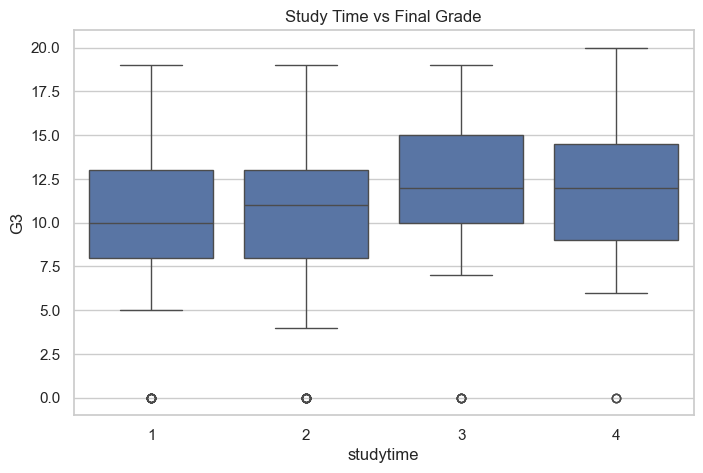

In [12]:
plt.figure(figsize=(8,5))

sns.boxplot(x="studytime", y="G3", data=df)

plt.title("Study Time vs Final Grade")

plt.show()

Nhận xét:
- Nhóm học sinh học nhiều có xu hướng điểm G3 cao hơn.

Absences vs Final Grade

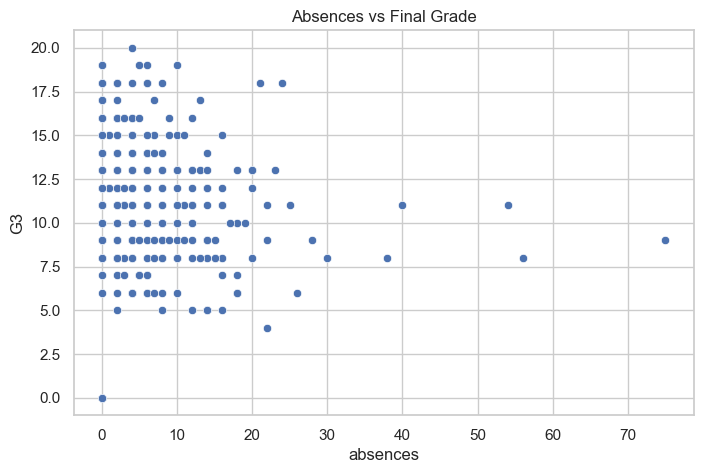

In [13]:
plt.figure(figsize=(8,5))

sns.scatterplot(x="absences", y="G3", data=df)

plt.title("Absences vs Final Grade")

plt.show()

Nhận xét:
- Học sinh nghỉ học nhiều có xu hướng điểm thấp hơn.
- Tuy nhiên dữ liệu phân tán → mối quan hệ không hoàn toàn tuyến tính.

Gender vs Final Grade

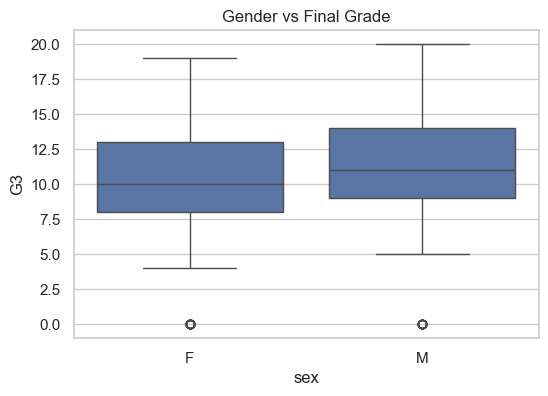

In [14]:
plt.figure(figsize=(6,4))

sns.boxplot(x="sex", y="G3", data=df)

plt.title("Gender vs Final Grade")

plt.show()

Failures vs Final Grade

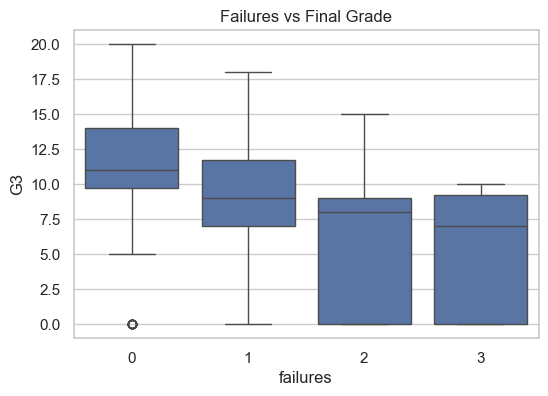

In [15]:
plt.figure(figsize=(6,4))

sns.boxplot(x="failures", y="G3", data=df)

plt.title("Failures vs Final Grade")

plt.show()

Nhận xét:
- Học sinh có nhiều failures thường có điểm thấp hơn.
- Đây là yếu tố ảnh hưởng mạnh.

Correlation Matrix

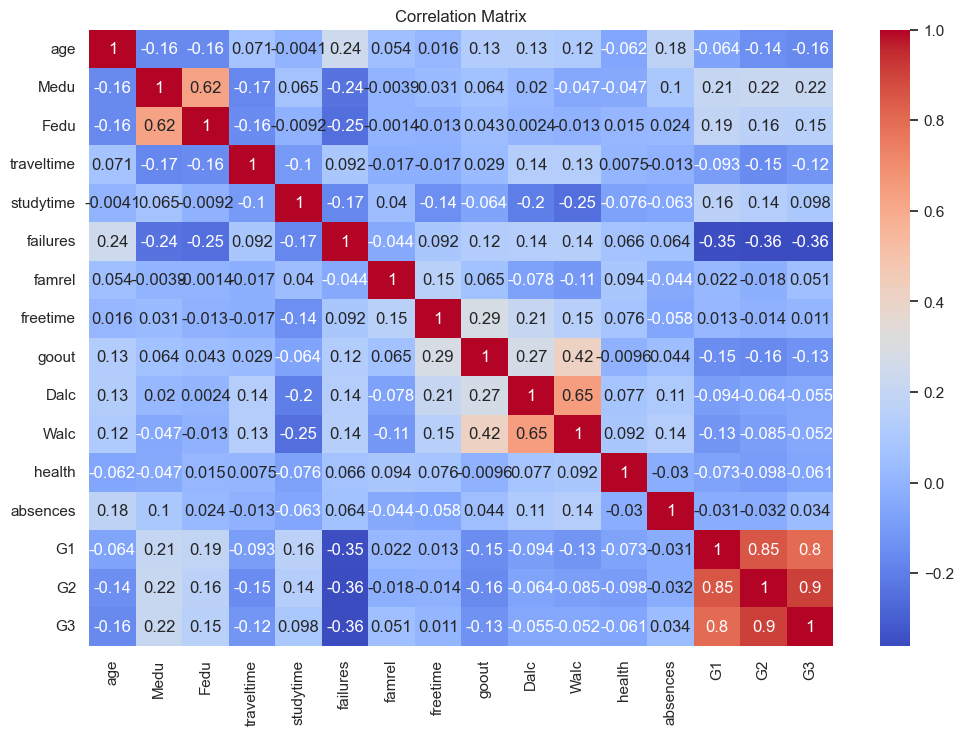

In [16]:
plt.figure(figsize=(12,8))

corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

Correlation with Final Grade

In [17]:
corr["G3"].sort_values(ascending=False)

G3            1.000000
G2            0.904868
G1            0.801468
Medu          0.217147
Fedu          0.152457
studytime     0.097820
famrel        0.051363
absences      0.034247
freetime      0.011307
Walc         -0.051939
Dalc         -0.054660
health       -0.061335
traveltime   -0.117142
goout        -0.132791
age          -0.161579
failures     -0.360415
Name: G3, dtype: float64

 Nhận xét:
- G1 và G2 có tương quan rất cao với G3 → nguy cơ data leakage.
- failures có tương quan âm → học sinh trượt nhiều điểm thấp.
- studytime có tương quan dương nhẹ.

## Create Target Variable

Biến "pass" được tạo dựa trên điểm cuối kỳ (G3).

Nếu G3 >= 10 → pass = 1  
Nếu G3 < 10 → pass = 0

In [18]:
df["pass"] = (df["G3"] >= 10).astype(int)

df[["G3","pass"]].head()

,G3,pass
0,6,0
1,6,0
2,10,1
3,15,1
4,10,1


Pass vs Fail Distribution

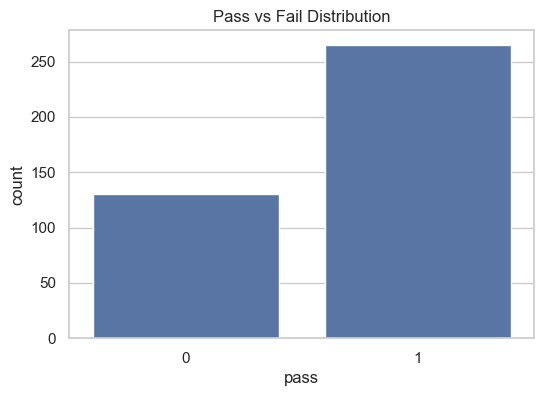

In [19]:
plt.figure(figsize=(6,4))

sns.countplot(x="pass", data=df)

plt.title("Pass vs Fail Distribution")

plt.show()

Save Clean Dataset

In [20]:
df.to_csv("../data/processed/student_clean.csv", index=False)

print("Processed dataset saved")

Processed dataset saved


### Check Class Distribution
Kiểm tra mất cân bằng lớp

In [21]:
df["pass"].value_counts()
df["pass"].value_counts(normalize=True)

pass
1    0.670886
0    0.329114
Name: proportion, dtype: float64

## Key Insights from EDA

Từ quá trình phân tích dữ liệu, có thể rút ra một số nhận xét:

1. Học sinh có nhiều lần trượt môn (failures cao) cần được hỗ trợ học tập sớm.

2. Giảm số buổi nghỉ học (absences) có thể giúp cải thiện kết quả học tập.

3. Tăng thời gian học (studytime) có xu hướng giúp nâng cao điểm số.

4. Học sinh có G1 và G2 thấp cần được theo dõi và can thiệp sớm.

5. Có thể xây dựng hệ thống cảnh báo sớm dựa trên các yếu tố như absences, failures và studytime.

In [22]:
df.to_csv("../data/processed/student_clean.csv", index=False)

print("Processed dataset saved")

Processed dataset saved
